# Lab class 2 Exercise Sheet

Preliminary: If you haven’t completed last weeks’ lab class, I would suggest you do so. If you have completed it, please proceed with the questions below.

# Question 1

#### You have a random graph with a mean degree of 4 and a mean excess degree of 4. You then decide to remove all nodes of degree 0 and 1. Do you expect the mean excess degree to go up or down? 
(hint: remember the definition of excess degree)

---

* [Initial notes and thoughts:](#initial-notes-and-thoughts)
* [Question 1 Answer](#question-1-answer)
* [Calculating Mean Excess Degrees](#calculating-mean-excess-degrees)
* [Addressing the Removal of Degree-0 Nodes](#addressing-the-removal-of-degree-0-nodes)
* [Addressing the Removal of Degree-1 Nodes](#addressing-the-removal-of-degree-1-nodes)

## Initial notes and thoughts:

#### Mean Degrees, Excess Degrees, Mean Excess Degress

**Mean degrees** is the average number of degrees a node has. it will be calculated using the sum of degrees over the number of nodes. Mean degree gives us no intution of the spread of degrees in our network.

**Excess Degrees** is a concepted used to describe the connectivity of a node reached by following a specific edge, rather than just picking a node at random from the entire network. The excess degree of a node $k$ is $k - 1$. it represents the number of edges connected to a node excluding the edge that was used to reach it.

The **Mean Excess Degrees** of a network is the average number of connections a randomly chosen neighbour has, excluding the link you used to get to that neighbor.

If you pick a node at **random**, its expected degree is simply $\langle k \rangle$ (average degree). If you pick an edge at random and follow it to a node, you are more likely to land on a Hub because hubs have so many "entry points" (links).

The Mean Excess Degree isn't about picking a node; it’s about following an edge. It is given by: $$\langle k_{excess} \rangle = \frac{\langle k^2 \rangle}{\langle k \rangle} - 1$$

We are squaring the degrees in the numerator because we want to give more weight to hubs which dominate the landscape of the network. This is a Weighted Mean of the degrees, where the "weight" of each node is its own degree. The numerator is just normalising the formula by the average degrees. Strictly speaking this is a simplification from this formula:
 
$$\frac{(\sum k_i^2) / N}{(\sum k_i) / N} = \frac{\langle k^2 \rangle}{\langle k \rangle}$$

Knowing the simplication allows us to calculate the Mean Excess Degrees from pre-computed summary stats rather than having to do the summation everytime. 

#### "Moments" Terminology
The mean degrees $\langle k \rangle$ is referred to as the **First Moment**, where as, the average of the sum of squared degrees $\langle k^2 \rangle$ is known as the **Second Moment**.

#### Perfect Grid Example
In a perfect grid, where everyone has 4 friends, the formilas would come out like this:
* First Moment (Average Degree $\langle k \rangle$): Since every node is the same, the average is just 4.
* Second Moment ($\langle k^2 \rangle$): Every node's degree squared is $4^2 = 16$.
* $\langle k_{excess} \rangle = \frac{16}{4} - 1$, $\langle k_{excess} \rangle = 4 - 1$, $\langle k_{excess} \rangle = \mathbf{3}$
* This result of 3 is mathematically guaranteed for any 4-regular network because there is no variance.

Note, you subtract 1 because that is the edge you just traveled along to arrive at the node. You are left with exactly 3 "excess" edges to continue the path.

#### Hubs and Heterogeneous Networks
In a scale-free or random network, following an edge usually leads you to a "Hub" (a node with a degree higher than the average), which pulls the calculation up. If you calculate a Mean Excess Degree that is higher than $\langle k \rangle - 1$, you have proof that your network is heterogeneous and contains hubs, to some extent. 

The distance between the Average Degree ($\langle k \rangle$) and the Mean Excess Degree ($\langle k_{excess} \rangle$) is a direct measure of how "hub-dominated" your network is. 3 acts as a floor, this is perfectly homogenous. As the number climbs far above $\langle k \rangle - 1$, the "Friendship Paradox" intensifies. If $\langle k_{excess} \rangle$ is 10 or 20 while the average is only 4, your network is being completely run by massive hubs. Because scale-free networks follow a Power Law ($P(k) \sim k^{-\gamma}$), adding a single new hub doesn't just increase the excess degree by "+1"; it can cause it to jump exponentially

---

## Question 1 Answer

To address this question, we first need a solid understanding of how Mean Excess Degree is calcualted. 

---

### Calculating Mean Excess Degrees

It is composed of 3 steps: first moment, second moment and arrival edge. 

$$\langle k_{excess} \rangle = \frac{\langle k^2 \rangle}{\langle k \rangle} - 1$$

To compute the first moment, we are just calculating the average degrees. 
* Sum the degrees: $1 + 2 + 2 + 5 = 10$.
* Divide by $N$: $10 / 4 = \mathbf{2.5}$.
* $\langle k \rangle = 2.5$.

To compute the second moment, we are averaging the sum of the **squared degrees**. It is the squaring that amplifies the hubs with larger degrees. 
* Square each degree: $[1^2, 2^2, 2^2, 5^2] \rightarrow [1, 4, 4, 25]$.
* Sum the squares: $1 + 4 + 4 + 25 = 34$.
* Divide by $N$: $34 / 4 = \mathbf{8.5}$.
* $\langle k^2 \rangle = 8.5$.

Finally, we combine and subtract the arrival edge. This is to avoid double counting edges for every node. 
* Divide the moments: $\frac{8.5}{2.5} = 3.4$.
* Subtract 1: $3.4 - 1 = \mathbf{2.4}$.
* Final Mean Excess Degree: $2.4$.

<br>

---

## Addressing the Removal of Degree-0 Nodes

To undestand the impact of removing nodes with 0 degrees, we first need understand how the impact this calculation in the first place. 

#### First Moment

For the average degrees $\langle k \rangle$, **the first moment**, a node of 0 degrees only shows up in the denominator, where it increments it by one. The numberator counts the degree meaning nothing changes. Nodes with a degree of 0 essentially dilute the average degrees. If you remove these nodes, this has the effect of increasing the average degree. 

#### Second Moment

For the second moment $\langle k^2 \rangle$, the sum of squaring the degree, the impact is the same, it is an incremement to the denominator and therefore dilutes and scales the metric. 

#### Proportional Impact of $N$

Remember, both moments are themsevles averages and therefore normailzed by $N$. This means that for both metrics, the inclusion of 0 nodes scales the numerator. But it does it proportionally for both moments meaning that they effectively cancel out. There is no impact the the output of the ratio itself. 

You could visualise this formula wise as the $N$ cancelled out, leaving behind the mean excess degree calculation $\frac{\sum k_i^2}{\sum k_i}$ whereby adding a node with $k=0$ adds nothing to the top ($\sum k_i^2$) and adding a node with $k=0$ adds nothing to the bottom ($\sum k_i$), meaning the ratio remains the same. 

$$\frac{\langle k^2 \rangle}{\langle k \rangle} = \frac{\frac{\sum k_i^2}{N}}{\frac{\sum k_i}{N}} = \frac{\sum k_i^2}{N} \cdot \frac{N}{\sum k_i} = \frac{\sum k_i^2}{\sum k_i}$$

#### Result of Removing 0-Degree Nodes

Therefore, considering a network with a mean degree of 4 and a mean excess degree of 4, removing all of the 0 degree nodes would result in no change to the excess degrees 

<br>

---

### Addressing the Removal of Degree-1 Nodes

#### Initial Formula Based Intuition

**Degree-0** nodes have no impact on the numerator of the first or second moments because their degree ($k=0$) adds nothing to the sum. While they increase the total number of nodes ($N$), they dilute both moments proportionally, leaving the ratio $\langle k^2 \rangle / \langle k \rangle$ unchanged.

**Degree-1** nodes, however, act as "diluters" for both moments. For the **mean degree** ($\langle k \rangle$), adding a degree-1 node adds 1 to the numerator but also 1 to the denominator. If the existing average is 4, adding a "1/1" contributor pulls the average down toward 1

For the **second moment** ($\langle k^2 \rangle$), this effect is even more dramatic. Since $1^2 = 1$, a degree-1 node adds the same value (1) to the numerator as it does to the denominator. Because the sum of squares in the numerator is typically much larger than $N$, adding 1 to the numerator is a negligible percentage increase, while adding 1 to $N$ is a significant percentage increase. Therefore, including degree-1 nodes significantly lowers the second moment. Consequently, **removing them** causes both $\langle k \rangle$ and $\langle k^2 \rangle$ to rise, with the second moment rising more sharply, **which mathematically increases the mean excess degree.**

---

#### The Counter-Intuition: Why Degree-1 Nodes Have "No Effect" on Excess Degree
This logic is correct for the **moments of the node distribution**. However, it is recommened to use an **edge-centric** definition. In large, uncorrelated networks, nodes of degree 0 and 1 effectively contribute "zero" to the branching process of the network.

The mean excess degree measures how many new edges you find when you arrive at a node via a random link. If you follow an edge and land on a degree-1 node, you have exactly zero other edges to follow to continue your journey ($1 - 1 = 0$). Because a degree-1 node offers zero "excess" edges, it acts as a "dead end."

The trick to understanding this is to look at the formula for **Mean Excess Degrees** using raw sums rather than moments: 

$$\langle k_{e} \rangle = \frac{\sum k_i(k_i - 1)}{\sum k_i}$$

* **For a degree-0 node:** $0(0-1) = 0$. It adds nothing to the top or bottom.
* **For a degree-1 node:** $1(1-1) = 0$. It adds zero to the numerator. It does add 1 to the denominator (the total sum of degrees).

---

#### The Variance Perspective 
To see why the ratio $\langle k^2 \rangle / \langle k \rangle$ appears to change, but the Mean Excess Degree effectively doesn't in large uncorrelated networks, we have to look at the "hidden" third term: The Variance.

The ratio can be rewritten using the average degree ($\langle k \rangle$) and the variance ($\sigma^2$):

$$\frac{\langle k^2 \rangle}{\langle k \rangle} = \langle k \rangle + \frac{\sigma^2}{\langle k \rangle}$$

When you remove degree-1 nodes from an Erdős–Rényi (ER) network:
* The Mean ($\langle k \rangle$) goes up (because you removed low-degree nodes).
* The Variance ($\sigma^2$) goes down (because the distribution becomes "tighter" and less spread out).

In a large, uncorrelated random graph, these two movements perfectly cancel each other out. As the mean rises, the variance drops by just enough to keep the ratio $\langle k^2 \rangle / \langle k \rangle$ constant.

The most "Plain English" way to see why it fails to change is to look at the raw sums. Let’s call the sum of all degrees $S_1$ and the sum of all squared degrees $S_2$.

$$\langle k_{excess} \rangle = \frac{S_2}{S_1} - 1$$

Now, let's remove one node of degree 1:
* New $S_2$: You subtract $1^2$, so the new sum is $S_2 - 1$.
* New $S_1$: You subtract the degree itself, so the new sum is $S_1 - 1$.

The new ratio is $\frac{S_2 - 1}{S_1 - 1}$.

Mathematically, a fraction $\frac{A-1}{B-1}$ is only equal to $\frac{A}{B}$ if $A = B$.

In your specific problem, the Mean Degree was 4 and the Mean Excess Degree was 4. If the Excess Degree is 4, then the "Arrival Degree" ($\langle k^2 \rangle / \langle k \rangle$) must be 5.
If the ratio is $5/1$, then $S_2$ is exactly 5 times larger than $S_1$.

Example:
* Imagine $S_2 = 100$ and $S_1 = 20$. Ratio = $100/20 = 5$.
* Remove a degree-1 node: $(100 - 1) / (20 - 1) = 99 / 19 \approx 5.21$.

Wait! The ratio went up! You were right! So why does the professor say it stays the same?

#### Interdependancy of Nodes in the Formula
The correct way to view the network is as **Infinite** and **Uncorrelated**. In that theoretical world, when you remove a degree-1 node, you aren't just removing a node; you are also removing the **edge** that was connected to it. When that edge is removed, it was connected to some other node elsewhere in the network. That "other" node just had its degree reduced by 1.

My original initution, applying changes direct to the first and second moment only account for the remove of the 1-degree node(s) insolation. To correctly apply the changes, we need to account for the fact that very time you remove a degree-1 node, you change the degree of a neighbor somewhere else.

In an uncorrelated network, the "loss" of that connection on the neighbor perfectly offsets the "gain" in the average caused by removing the degree-1 node. This is why the professor mentions Probability Generating Functions—they track how the entire distribution reshapes itself when edges are clipped.

---

#### Summary

In a large, uncorrelated network (like an Erdős-Rényi graph), the "expected" number of neighbors for any node you reach is determined by the global connectivity, not by the presence of dead ends. When you remove a degree-1 node, you are removing a node that had a "0" excess degree. In a perfectly uncorrelated system, removing a "zero" from a weighted average of edges doesn't change the expected outcome for the other edges.

Trying to look at the formulas described how the **statistical properties of the nodes** change but the correct way to view it is through how the **navigational properties of the edges remain constant.**


In [2]:
import networkx as nx
import numpy as np

# Function to calculate mean degree
def mean_degree(G):
    degrees = [deg for _, deg in G.degree()]
    return np.mean(degrees)

# Function to calculate mean excess degree
def mean_excess_degree(G):
    degrees = np.array([deg for _, deg in G.degree()])
    if np.sum(degrees) == 0:
        return 0 # Avoid division by zero
    return np.sum(degrees * (degrees - 1)) / np.sum(degrees)

# Generate a large Erdős-Rényi (ER) network with low probability
N_large = 2000
p_low = 0.002 # Low probability to ensure nodes with degree 0 and 1

num_experiments = 100
mean_degrees_before = []
mean_excess_degrees_before = []
mean_degrees_after = []
mean_excess_degrees_after = []
nodes_removed_counts = []

for _ in range(num_experiments):
    er_graph_low_p = nx.erdos_renyi_graph(n=N_large, p=p_low)
    
    # Calculate mean degree and mean excess degree before removing nodes
    er_mean_k_before = mean_degree(er_graph_low_p)
    er_mean_excess_k_before = mean_excess_degree(er_graph_low_p)
    
    # Remove nodes with degree 0 and 1
    nodes_to_remove = [
        node for node, degree in dict(er_graph_low_p.degree()).items()
        if degree <= 1
    ]
    er_graph_low_p.remove_nodes_from(nodes_to_remove)

    # Calculate mean degree and mean excess degree after removing nodes
    er_mean_k_after = mean_degree(er_graph_low_p)
    er_mean_excess_k_after = mean_excess_degree(er_graph_low_p)
    
    # Store results
    mean_degrees_before.append(er_mean_k_before)
    mean_excess_degrees_before.append(er_mean_excess_k_before)
    mean_degrees_after.append(er_mean_k_after)
    mean_excess_degrees_after.append(er_mean_excess_k_after)
    nodes_removed_counts.append(len(nodes_to_remove))

# Print results
print(f"Before removal: \
Mean Degree = {np.mean(mean_degrees_before):.2f}, \
Mean Excess Degree = {np.mean(mean_excess_degrees_before):.2f}")
print(f"After removal: \
Mean Degree = {np.mean(mean_degrees_after):.2f}, \
Mean Excess Degree = {np.mean(mean_excess_degrees_after):.2f}")
print(f"Average number of nodes removed (degree 0 and 1): \
{np.mean(nodes_removed_counts):.2f}")

Before removal: Mean Degree = 4.00, Mean Excess Degree = 3.99
After removal: Mean Degree = 4.24, Mean Excess Degree = 3.99
Average number of nodes removed (degree 0 and 1): 183.31


# Question 2

Keeping in mind the definition of excess degree, an interesting question is the relationship between mean degree and mean excess degree for a given network. Do you expect it to be generally lower?

---

$\langle k_{excess} \rangle = \frac{\langle k^2 \rangle}{\langle k \rangle} - 1$

* [Notes on my general intution](#notes-on-my-general-intution)
* [Write code to generate the following 3 networks:](#write-code-to-generate-the-following-3-networks)
* [Regular network](#regular-network)
* [Erdos-Renyi Random Network](#erdos-renyi-random-network)
* [Barabasi-Albert Random Network](#barabasi-albert-random-network)
* [Write functions to extract the mean degree and mean excess degrees](#write-functions-to-extract-the-mean-degree-and-mean-excess-degrees)
* [What do you notice regarding the relationship between mean degree and mean excess degree?](#what-do-you-notice-regarding-the-relationship-between-mean-degree-and-mean-excess-degree)

#### Notes on my general intution:

The formula for mean excess degrees is is the second moment over the first moment, whereby the first moment is the mean degrees. The second moment is the average of the squared degrees. Finally, we minus one to remove the travelling links, otherwise we would double count each link. 

The LHS of the formula is a ratio against the mean degrees. That means, if we ignore the $-1$, for the ratio to be larger than mean degrees, the second moment, which is the mean squared degrees, just needs to be $k$ times larger than the mean degrees.

$\frac{4}{2}=2$: Here, the numerator is $k=2$ to the power of the denominator. However, this only brings it in line with the mean degree, meaning the $-1$ offset will take it down. 

I predict that this means, the mean degrees will only exceed the mean degrees in networks that are highly heterogeneous and have the characteristic/existence of hubs. However, in homogenous, or just weakly heterogeneous networks, the squaring effect of the second momment will not amplify the numerator enough to scale to a value that exceed the mean degress.

---

#### Feedback from Gemini:

 It isn't just about being "larger"; it's specifically about the variance being larger than the mean. If $\sigma^2 > \langle k \rangle$, then the Mean Excess Degree will be higher than the Mean Degree.

 In statistics, the relationship between the first and second moment is defined by Variance ($\sigma^2$): $\langle k^2 \rangle = \langle k \rangle^2 + \sigma^2$

 $$\langle k_{excess} \rangle = \frac{\langle k \rangle^2 + \sigma^2}{\langle k \rangle} - 1 = \langle k \rangle + \frac{\sigma^2}{\langle k \rangle} - 1$$

 * If Variance ($\sigma^2$) is low (weakly heterogeneous), the term $\frac{\sigma^2}{\langle k \rangle}$ is small. Once you subtract the $1$, the result stays below $\langle k \rangle$.
 * If Variance is high (highly heterogeneous/hubs), $\sigma^2$ becomes massive. This "amplifies" the numerator enough to easily overcome the $-1$ offset.

 ---

### Write code to generate the following 3 networks:

* [Regular Network](#regular-network)
* [Edros-Renyi Random Network](#erdos-renyi-random-network)
* [Barabasi-Albert Random Netowrk](#barabasi-albert-random-network)

### Regular network

**Create:** "Regular network (nx.random_regular_graph(d, n)) with mean degree 4, i.e., all nodes have exactly degree 4."

---

The nx.random_regular_graph(d, n) function generates a $d$-regular graph with $n$ nodes. In network science, a "regular" graph is one where every single node has exactly the same degree $d$.

The product $n \times d$ must be even. This is because each edge connects two nodes; if $n \times d$ were odd, you would have a "half-edge" left over, which is mathematically impossible for a simple graph.

For a regular graph, the mean degrees $\langle k \rangle$ is just $d$ because every node has the same degrees. Additionally, the second moment, $\langle k^2 \rangle$ is just $d^2$ as there is no variance, every node has the same squared degree. This means we can simplfy the mean excess degrees calculation to just $d-1$.

$$\langle k_{excess} \rangle = \frac{d^2}{d} - 1 = d - 1$$

Mathematically, not every combination of nodes ($N$) and degree ($d$) is possible. To have a mean degree of exactly 4, a graph must satisfy two specific constraints:
1. **The Sum of Degrees must be Even:** This is known as the Handshaking Lemma. Every edge connects two nodes, so the sum of all degrees in any graph must be exactly twice the number of edges ($2E$). Because $2E$ is always an even number (anything multiplied by 2 is even), the sum of all degrees must be even.
2. **The Number of Nodes ($N$)** must be at least $d + 1$

That means, if our constraint is `mean_degrees = 4` then all we need to is set our node to be $>5$. this is because our function allows us to set the degrees for each nodes, `d=4`, meaning to set $N$ we just need to mathematically satisify the two constraints. We know that the number of degrees will be even because $4*n$ will be even. The second constraint just tells us that $N$ needs to be least $d + 1$, therefore $5$ is our min value. 

---

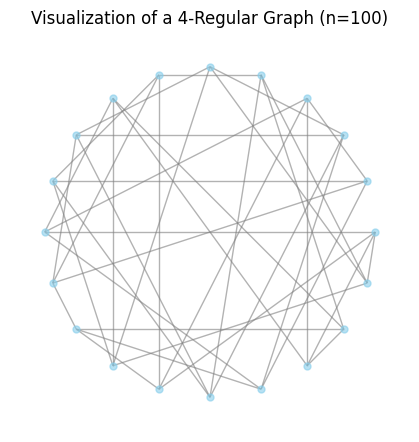

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create the 4-regular graph
G_rand = nx.random_regular_graph(d=4, n=20, seed=41)

# 2. Set the figure size (larger is better for 100 nodes)
plt.figure(figsize=(4, 4))

# 3. Use a Circular Layout to show the symmetry
pos = nx.circular_layout(G_rand)

# 4. Draw the graph
nx.draw(G_rand, pos, 
        node_size=25, 
        node_color='skyblue', 
        edge_color='gray', 
        alpha=0.6, 
        with_labels=False)

plt.title("Visualization of a 4-Regular Graph (n=100)")
plt.show()

**Circular Layout**:

To visualize a 100-node regular graph, you have to be careful. Because every node has exactly 4 edges, a standard "random" layout often looks like a tangled ball of yarn. The best way to see the regularity (the fact that everyone is equal) is to use a **Circular Layout**. This places the nodes in a perfect ring, making the 4-way symmetry much easier to spot.

---

### Erdos-Renyi Random Network

**Create**: Erdos-Renyi random network (nx.erdos_renyi_graph(n, p)) also with mean degree 4.

> We will study this model in more detail very shortly but for now all you need to know is that that in an ER network, the mean degree ⟨𝑘⟩ is given by 𝑝(𝑁 − 1) where 𝑝 is the probability of a node being connected and 𝑁 is the size of the network. So set 𝑝 so that the ⟨𝑘⟩ can be expected to be 4.

$$\langle k \rangle = p(n - 1)$$

<br>

---

A ER (Erdős-Rényi) network is the polar opposite of a Scale-Free network. The difference lies in the Degree Distribution—the mathematical "shape" of how many friends nodes have. In an ER network, the degrees follow a Poisson Distribution (a Bell Curve). Most nodes have a degree very close to the average ($\langle k \rangle$). It is exponentially rare to find a node with a degree much higher than the average. There are no hubs. In a 100-node ER graph with $\langle k \rangle = 4$, you might find a node with 8 or 9 edges, but you will almost never find one with 50.


---

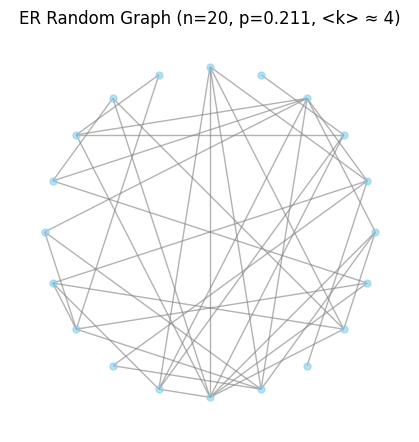

In [53]:
import networkx as nx
import matplotlib.pyplot as plt

n = 20
target_k = 4
p = target_k / (n - 1)  # Calculate p automatically

# 1. Create the Erdos-Renyi random network 
G_erdos = nx.erdos_renyi_graph(n=n, p=p, seed=41)

# 2. Set the figure size (larger is better for 100 nodes)
plt.figure(figsize=(4, 4))

# 3. Use a Circular Layout to show the symmetry
pos = nx.circular_layout(G_erdos)

# 4. Draw the graph
nx.draw(G_erdos, pos, 
        node_size=25, 
        node_color='skyblue', 
        edge_color='gray', 
        alpha=0.6, 
        with_labels=False)

plt.title(f"ER Random Graph (n={n}, p={p:.3f}, <k> ≈ {target_k})")
plt.show()

### Barabasi-Albert Random Network

Barabasi-Albert Random Network (nx.barabasi_albert_graph(n, m)) also with mean degree 4.

We will also study this model in more detail. Here ensuring the mean degree is 4 is a bit tricky. For the purpose of this exercise, simply set the parameter 𝑚 to 2. This parameter has to be an integer so this will not be exact (see below).

<br>

---

This should be a scale-free network (?)

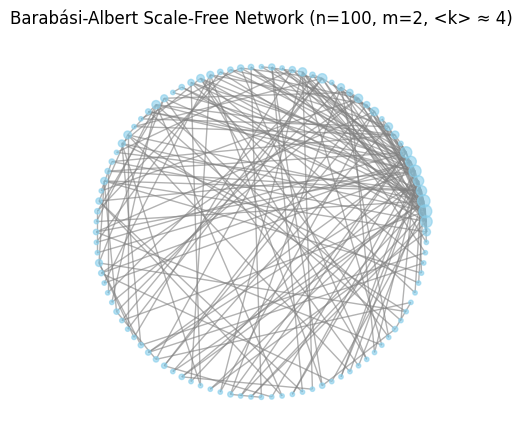

In [58]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Parameters ---
n = 100
target_k = 4
m = target_k // 2  # For BA graphs, mean degree <k> is approximately 2 * m

# 1. Create the Barabási-Albert (Scale-Free) network 
G_bara = nx.barabasi_albert_graph(n=n, m=m, seed=41)

# 2. Set the figure size
plt.figure(figsize=(4, 4))

# 3. Use a Circular Layout
# Note: Hubs will appear as nodes with many "chords" crossing the circle
pos = nx.circular_layout(G_bara)

# 4. Draw the graph
# Optional: scale node_size by degree to visually identify the hubs
degrees = [G_bara.degree(node) for node in G_bara.nodes()]
node_sizes = [d * 5 for d in degrees] 

nx.draw(G_bara, pos, 
        node_size=node_sizes, 
        node_color='skyblue', 
        edge_color='gray', 
        alpha=0.6, 
        with_labels=False)

plt.title(f"Barabási-Albert Scale-Free Network (n={n}, m={m}, <k> ≈ {target_k})")
plt.show()

### Write functions to extract the mean degree and mean excess degrees

In [61]:
import numpy as np

def calculate_network_stats(G):
    # 1. Get a list of all degrees
    degrees = [d for n, d in G.degree()]
    
    # Handle empty graphs to avoid division by zero
    if not degrees or len(degrees) == 0:
        return 0, 0, 0

    # 2. Calculate First Moment (Mean Degree)
    k_avg = np.mean(degrees)
    
    # 3. Calculate Second Moment (Mean Squared Degree)
    k2_avg = np.mean([k**2 for k in degrees])
    
    # 4. Calculate Mean Excess Degree
    # Formula: (<k^2> / <k>) - 1
    if k_avg > 0:
        excess_degree = (k2_avg / k_avg) - 1
    else:
        excess_degree = 0
        
    return k_avg, k2_avg, excess_degree

In [79]:
Gr = calculate_network_stats(G_rand)
Ge = calculate_network_stats(G_erdos)
Gb = calculate_network_stats(G_bara)

print(f"Rand:  [First: {Gr[0]:.2f}, Second: {Gr[1]:.2f}, Mean Excess: {Gr[2]:.2f}]")
print(f"Erdos: [First: {Ge[0]:.2f}, Second: {Ge[1]:.2f}, Mean Excess: {Ge[2]:.2f}]")
print(f"Bara:  [First: {Gb[0]:.2f}, Second: {Gb[1]:.2f}, Mean Excess: {Gb[2]:.2f}]")

Rand:  [First: 4.00, Second: 16.00, Mean Excess: 3.00]
Erdos: [First: 4.00, Second: 19.20, Mean Excess: 3.80]
Bara:  [First: 3.92, Second: 26.16, Mean Excess: 5.67]


### What do you notice regarding the relationship between mean degree and mean excess degree?

**Random:** This has a mean excess of less than 4. This to be expects as we directed the graph to have a mean degree of 4 whereby every node has 4 degrees. There is no variance ($\sigma^2 = 0$) to the excess degrees formula reduces down to $k-1$. Following an edge always leads to a node with 4 friends. You subtract the "arrival" edge, and you are left with exactly 3 ways to continue. This is the absolute mathematical minimum for a network with an average degree of 4.

**Eros**: This has a mean excess which is slightly less than 4. The theoretical "limit" for a massive, infinite ER graph is $\langle k_{excess} \rangle = \langle k \rangle$, in a real-world simulation with a finite number of nodes, you will almost always see a value slightly below the mean degree. In an ER graph of this size, the degree distribution is a Poisson distribution. Because the network is random and relatively small: Most nodes have degrees like 3, 4, or 5. It is extremely rare to have a "Hub" (a node with degree 15+). Because you are missing those high-degree nodes that "explode" the second moment ($\langle k^2 \rangle$), the numerator in your fraction doesn't grow fast enough to overcome the $-1$ at the end of the formula. In a random network, there aren't really "hubs," just nodes that got a little luckier than others (e.g., a node with 6 friends instead of 4). 

For a finite ER graph, the relationship is actually:

$$\langle k^2 \rangle = \langle k \rangle^2 + \langle k \rangle \left(1 - \frac{1}{n-1}\right)$$

When you plug this into the excess degree formula $\frac{\langle k^2 \rangle}{\langle k \rangle} - 1$:

$$\langle k_{excess} \rangle = \langle k \rangle - \frac{\langle k \rangle}{n-1}$$

Using your numbers ($\langle k \rangle = 4, n = 101$):

$$\langle k_{excess} \rangle = 4 - \frac{4}{100} = \mathbf{3.96}$$

**Barabási**: Here, the mean excess has gone above 4 to 5.67. The facilitation of hubs and hetro has introduced variance and pushed up the excess degrees. Even though the average degree is the lowest of the three (3.92), the Second Moment (26.16) is massive. This happens because squaring a Hub's degree (e.g., $15^2 = 225$) adds way more weight to the numerator than many small nodes. The heterogeneity (hubs) has broken the "ceiling" of 4.0. In this network, if you follow a random edge, you are statistically likely to end up at a node that has more friends than the person you started with.

---

# Question 3

A network has a mean degree of 4 and a mean excess degree of 6, then half the nodes are removed at random. What is your expectation for the mean degree and mean excess degree after the nodes have been removed? Before using any code, try to predict the answer. 

Once you have your prediction, use code above to check whether your prediction is correct. To be clear, you will not get a network with a mean degree of 4 and a mean excess degree of 6, but using those 3 networks, you will learn that the impact is identical between all 3 types of networks. Now, to get better results, make the networks suﬀiciently large (the larger, the better).

---

**Prediction:**

My prediction is that, for the bara, both metric will drop but the mean excess degrees will drop dramatically. This is because this hetro, hub-based based network is vulnerable to attack. If you are randomly removing nodes, and nodes have a higher chance of being connected to a hubs, then removing nodes is attacking the hub. It is the hub that increasing the variance, therefore the excess degrees will drop dramatically. Additionally, depending on the run, the attack may hit the hub itself, in which case the network itself will be decimated. 

--- 

**Gemini Feedback:**

This intuition is not quite correct. Hubs are incredibily rare so it not statistically correct to consider this route, though it can happen. When you remove nodes it is true that you are more likely to remove an edge from a hub. But these removed nodes are generally low-level anchors or hubs that are being removed from the network, i.e. in our earlier question where we deleted Degree-1 nodes. 

However, it is note quite the same as simply deleting degree-1 nodes. There exists a massive difference between filtering (removing nodes because they have degree 1) and random deletion (removing nodes regardless of their degree). When we targeted the degree-1 nodes, this has the effect of inflating the overall average as the weighting of $\frac{1}{1}$ nodes were gone from the averaging equation and the $\frac{4}{1}$, $\frac{10}{1}$ nodes could prevail. 

In Random Removal, you aren't filtering. You are deleting nodes blindly. You delete some Degree-1 nodes (Anchors). You delete some Degree-4 nodes (Average). You might even delete a Hub. Additionally, when you delete a node at random, you aren't just deleting the node, you are also deleting at least 1 edge, i.e. the connecting the deleted node to another. The deleted nodes are deleting degrees. Mathematically, if you remove a fraction $f$ of nodes, the new mean degree $\langle k' \rangle$ follows this rule: $\langle k' \rangle = \langle k \rangle \times (1 - f)$. So if you remove 50% ($f=0.5$), your mean degree of 4 will drop to 2 

* When you removed Degree-1 nodes earlier, you were pruning. It’s like a gardener only cutting off the dead leaves; the "trunk" (the hubs) stays strong, so the average health goes up.
* Random removal is like a hailstorm. It hits the leaves, but it also hits the branches and the trunk. Because the hailstorm destroys the "friends" of the survivors, the survivors end up lonelier.

Because Hubs are so well-connected, they are very "sturdy." Even if a Hub loses half its edges, it might still have 20 edges left, while a normal node drops from 4 to 2. Mean Degree drops linearly (4 $\rightarrow$ 2). Variance stays high because the surviving Hubs are still much larger than the surviving Anchors. Mean Excess Degree will drop, but it will not drop as fast as the mean degree. It stays "inflated" because the remaining hubs still dominate the Second Moment.

<br>

| Scenario | Mean Degree (⟨k⟩) | Mean Excess (⟨kex​⟩) |
| :--- | :--- | :--- |
| Remove Degree-1 only | Increases (Pruning effect) | Increases (Variance spikes) |
| Remove 50% Randomly | Decreases (Everyone loses friends) | Decreases (But stays above ⟨k⟩) |


**Getting a mean degree of 4 and an excess of 6:**

Since a standard $d=4$ regular graph has an excess degree of 3, and a random ER graph has an excess degree of ~4, we must use a Scale-Free (Barabási) or a custom heterogeneous graph to hit that 6.0 mark.

In [81]:
import networkx as nx
import numpy as np
import random

def get_stats(G):
    degrees = [d for n, d in G.degree()]
    if not degrees: return 0, 0, 0
    k = np.mean(degrees)
    k2 = np.mean([d**2 for d in degrees])
    excess = (k2/k) - 1 if k > 0 else 0
    return k, k2, excess

def random_remove_50_percent(G):
    nodes = list(G.nodes())
    random.shuffle(nodes)
    nodes_to_remove = nodes[:len(nodes)//2]
    G_new = G.copy()
    G_new.remove_nodes_from(nodes_to_remove)
    return G_new

# --- Setup ---
n = 2000

# 1. Regular: Always stays at Excess = 3.0
G_reg = nx.random_regular_graph(d=4, n=n)

# 2. ER: Always stays near Excess = 4.0
G_er = nx.erdos_renyi_graph(n=n, p=4/(n-1))

# 3. Bara: Targeted to hit <k> ~ 4 and Excess ~ 6
# We use a 7-node clique as a seed to boost initial hubs
seed_clique = nx.complete_graph(7)
G_ba = nx.barabasi_albert_graph(n=n, m=2, initial_graph=seed_clique, seed=42)

networks = [("Regular", G_reg), ("Erdos", G_er), ("Bara", G_ba)]

print(f"{'Network':<10} | {'Status':<10} | {'<k>':<6} | {'<k^2>':<6} | {'Excess'}")
print("-" * 55)

for name, G in networks:
    k_b, k2_b, ex_b = get_stats(G)
    print(f"{name:<10} | Before     | {k_b:<6.2f} | {k2_b:<6.2f} | {ex_b:.2f}")
    
    G_after = random_remove_50_percent(G)
    k_a, k2_a, ex_a = get_stats(G_after)
    print(f"{name:<10} | After (50%)| {k_a:<6.2f} | {k2_a:<6.2f} | {ex_a:.2f}")
    print("-" * 55)

Network    | Status     | <k>    | <k^2>  | Excess
-------------------------------------------------------
Regular    | Before     | 4.00   | 16.00  | 3.00
Regular    | After (50%)| 1.97   | 4.96   | 1.52
-------------------------------------------------------
Erdos      | Before     | 3.90   | 19.00  | 3.87
Erdos      | After (50%)| 1.96   | 5.83   | 1.98
-------------------------------------------------------
Bara       | Before     | 4.01   | 52.96  | 12.22
Bara       | After (50%)| 1.79   | 9.69   | 4.42
-------------------------------------------------------


#### Results

**The 50% Mean Degree Rule:**

In all three cases, the Mean Degree $\langle k \rangle$ dropped by almost exactly half:
* Regular: $4.00 \to 1.97$
* Erdos: $3.90 \to 1.96$
* Bara: $4.01 \to 1.79$ (Slightly lower because losing a hub kills more edges simultaneously).

**The Excess Degree "Half-Life":**

There Bara excess degree went from 12.22 to 4.42. This compared to the regular which has dropped to $1.52$ and the Erdos that has dropped to $1.98$. 

This proves that even after losing 50% of its nodes, the Barabási network is still more heterogeneous than a healthy Regular graph was at its peak. The "Hubs" may be smaller, but they are still hubs relative to their neighbors.

---

# Question 4

In the next lecture, we will introduce a property called **“degree assortativity”**, which, put simply, is a measure of the tendency of nodes to connect to other nodes with similar degree. Practically, degree assortativity is calculated using the **assortativity coeﬀicient** $𝑟$, which ranges from -1 **(perfect disassortativity)** to +1 **(perfect assortativity)**, with 0 indicating no correlation. To calculate the degree assortativity of a network $G$, use `nx.degree_assortativity_coefficient(G)`. 

In this exercise, I am asking you to write code to generate your own low- and high-assortativity networks (say with 100 nodes, i.e., I am not interested in a small hand-designed graph). Feel free to come up with your own approach but one idea might be to start from some kind of random network (and here you might want to pick a suitable form of random graph depending on whether you want high or low assortativity) and then do some rewiring to tune the assortativity up or down. 

(hint: the principle of a **rewiring algorithm** is that you will pick two pairs of nodes, one that is connected by an edge and one that isn’t, and then, delete the existing edge and add a new edge if it will either increase or decrease assortativity)

---

* [Question 4 Starting Notes:](#question-4-starting-notes)
* [Core Concept: Assortativity](#core-concept-assortativity)
* [The Relationship: $k$ vs. $\langle k_{nn} \rangle$](#the-relationship--vs)
* [Approach 1. Rewiring](#approach-1-rewiring)
* [Approach 2. Structured Block (High Assortativity)](#approach-2-structured-block-high-assortativity)
* [Approach 3. Star-Hub (Low Assortativity)](#approach-3-star-hub-low-assortativity)
* [Random Graphs Starting Assocativity:](#random-graphs-starting-assocativity)
* [Bara Rewrire Approach](#bara-rewrire-approach)
* [Question 4 Visualisation](#question-4-visualisation)
* [1. The "Neighbor Degree" Scatter Plot](#1-the-neighbor-degree-scatter-plot)
* [2. Network Layout Visualization](#2-network-layout-visualization)

## Question 4 Starting Notes:

Degree assortativity is essentially the "Birds of a feather flock together" principle of networks.

In an assortative network, hubs connect to hubs and loners to loners. In a disassortative network, hubs connect to loners (like a star or a service provider network).

## Core Concept: Assortativity

Assortativity measures the correlation between the degrees of nodes at either end of an edge.
* **Assortative ($r > 0$):** Hubs link to hubs; leaves link to leaves. (e.g., Social networks where celebrities follow celebrities).
* **Disassortative ($r < 0$):** Hubs link to leaves. (e.g., The Internet or biological networks where a central server connects to many end-users).
* **Neutral ($r \approx 0$):** Connections are random with respect to degree (e.g., Erdős-Rényi networks).

## The Relationship: $k$ vs. $\langle k_{nn} \rangle$


To analyze this, we plot the degree of a node ($k$) on the x-axis and the average degree of that node's neighbors ($\langle k_{nn} \rangle$) on the y-axis.
* **In an Assortative Network:** The line slopes **upward**. If you are a high-degree node, your neighbors are likely high-degree too.
* **In a Disassortative Network:** The line slopes **downward**. If you are a high-degree node, you are likely connected to many "leaves" with degree 1 or 2.
* **In a Neutral Network:** The line is **flat**. The degree of your neighbors is independent of your own degree and should be roughly equal to the Mean Excess Degree + 1.

## Approach 1. Rewiring

This is the most mathematically robust way. You start with a base graph (like your Bara or ER graph) and "evolve" it toward your target. 

The Strategy:
* Pick two edges at random: $(u, v)$ and $(x, y)$.
* Calculate the degree products or differences.
* Swap them: Try connecting $u$ to $x$ and $v$ to $y$.
* The Rule: If the swap makes the degrees of connected nodes more similar, keep it (to increase assortativity). If it makes them more different, keep it (to decrease assortativity).

There is a built-in function called `nx.random_reference(G)` that does some rewiring, but for a lab, you might want to implement a "greedy" swap loop using `nx.double_edge_swap`.

## Approach 2. Structured Block (High Assortativity)

If you want to build a High-Assortativity ($r \to 1$) network, you want nodes to only talk to their "social equals."

* Create 3 separate groups (cliques) of nodes.
    * Group A: 20 nodes, all connected (Degree = 19).
    * Group B: 30 nodes, connected in a ring (Degree = 2).
    * Group C: 50 nodes, sparsely connected (Degree = 1).
* Add just a few edges between the groups to keep it a single network.
* Result: Because the 19s only talk to 19s and the 1s only talk to 1s, the assortativity will be very high.


## Approach 3. Star-Hub (Low Assortativity)

Disassortative networks ($r \to -1$) are common in technology (like your phone connecting to a cell tower). Hubs connect to many nodes that have very few other connections.

The Strategy:

* Start with a Barabási-Albert graph. These are naturally slightly disassortative because new nodes (degree $m$) must connect to established hubs (high degree).
* To drive it even lower, perform a Targeted Rewire:
    * Specifically look for two edges where a hub is connected to another hub.
    * Break that, and force the hub to connect to a node with degree 1.
* Result: You create a "Hub-and-Spoke" model where big nodes are surrounded by tiny nodes.

## Random Graphs Starting Assocativity:

| Graph Type | Natural Assortativity | Reason | 
| :--- | :--- | :--- |
| Regular | 0.0 (Neutral) | Every node is identical. You can't be assortative if everyone has the same degree!
| Erdős-Rényi | ~0.0 (Neutral) | Connections are random; degree doesn't influence the choice. |
| Barabási | Slightly Negative | New nodes are forced to attach to big hubs. |

## Bara Rewrire Approach

By starting with a Barabási-Albert (BA) graph, you give yourself a "palette" of different node degrees (hubs and anchors) to work with.

In [87]:
import networkx as nx
import random
import matplotlib.pyplot as plt

def tune_assortativity(G, target="high", iterations=500):
    """
    Rewires a graph to increase or decrease degree assortativity.
    """
    G_tuned = G.copy()
    edges = list(G_tuned.edges())
    
    for _ in range(iterations):
        # 1. Pick two random edges (u, v) and (x, y)
        e1, e2 = random.sample(list(G_tuned.edges()), 2)
        u, v = e1
        x, y = e2
        
        # Ensure all four nodes are distinct to avoid self-loops
        nodes = {u, v, x, y}
        if len(nodes) < 4:
            continue
            
        # 2. Get degrees of these nodes
        # Sorting helps us decide how to pair them up
        # sorted_nodes will be [lowest_degree_node, ..., highest_degree_node]
        sorted_nodes = sorted(nodes, key=lambda n: G_tuned.degree(n))
        n_low1, n_low2, n_mid, n_high = sorted_nodes
        
        # 3. Define the "New" edges based on the goal
        if target == "high":
            # Connect Low-to-Low and High-to-High
            new_edges = [(n_low1, n_low2), (n_mid, n_high)]
        else:
            # Connect Low-to-High and Low-to-High (Disassortative)
            new_edges = [(n_low1, n_high), (n_low2, n_mid)]
            
        # 4. Check if the swap is valid (no existing edges, no self-loops)
        if not any(G_tuned.has_edge(*ne) for ne in new_edges):
            # Remove old
            G_tuned.remove_edge(u, v)
            G_tuned.remove_edge(x, y)
            # Add new
            G_tuned.add_edges_from(new_edges)
            
            # 5. Optional: Ensure the graph stays connected
            if not nx.is_connected(G_tuned):
                # Undo if it broke the graph
                G_tuned.remove_edges_from(new_edges)
                G_tuned.add_edge(u, v)
                G_tuned.add_edge(x, y)
                
    return G_tuned

# --- Workflow Execution ---
# Start with a base BA graph
G_base = nx.barabasi_albert_graph(n=100, m=2, seed=42)
r_base = nx.degree_assortativity_coefficient(G_base)

# Create high and low versions
G_high = tune_assortativity(G_base, target="high", iterations=1000)
r_high = nx.degree_assortativity_coefficient(G_high)

G_low = tune_assortativity(G_base, target="low", iterations=1000)
r_low = nx.degree_assortativity_coefficient(G_low)

print(f"Base BA Assortativity: {r_base:.3f}")
print(f"High Assortativity:    {r_high:.3f}")
print(f"Low Assortativity:     {r_low:.3f}")

Base BA Assortativity: -0.260
High Assortativity:    -0.065
Low Assortativity:     -0.440


---

## Question 4 Visualisation

To visualize the transition from a "natural" Barabási-Albert (BA) graph to one that is highly assortative or disassortative, you should use two specific techniques: 
1. Average Neighbor Degree Plots (to see the math)
2. Network Layouts (to see the clusters)


## 1. The "Neighbor Degree" Scatter Plot

**Purpose:** To show the statistical relationship between a node's degree and its neighbors' degrees.

What it proves: This is the actual "proof" of the $r$ coefficient.
* **High Assortativity:** A line sloping upwards.
* **Low Assortativity:** A line sloping downwards.

This is the "gold standard" for visualizing assortativity. It plots the degree of a node ($k$) on the x-axis and the average degree of its neighbors ($\langle k_{nn} \rangle$) on the y-axis.
* Assortative: You’ll see a clear upward slope (big nodes hang out with big nodes).
* Disassortative: You’ll see a downward slope (big nodes are babysitting small nodes).
* Neutral (ER): You’ll see a flat line (no correlation).

For a network to be assortative, high-degree nodes just need to be more likely to connect to other high-degree nodes than the small nodes are. If a node with $k=36$ has an average neighbor degree of 6, it is "reaching up" much higher than a node with $k=2$ whose neighbors are only $k=2$.

There can be an issue with small networks whereby the hubs connect to such a large proportion of the network that they don't get to "hang out" with out hubs. Or, it do, but they are connected to alot of the networks leaves/anchors which pulls does their neighbours average degrees. 

For each edge, you record the degree of the node at one end ($j$) and the degree of the node at the other end ($k$):
$$r = \frac{\sum_{jk} jk(e_{jk} - q_j q_k)}{\sigma_q^2}$$

The math essentially measures covariance. It asks: "If I know node $A$ has a very high degree, does that increase the statistical likelihood that its neighbor, node $B$, also has a high degree?"

* Positive $r$ (Assortative): High degrees are paired with high degrees more often than you would expect by pure chance.
* Negative $r$ (Disassortative): High degrees are paired with low degrees more often than chance (the "opposites attract" scenario).$r = 0$ 
* (Neutral): Knowledge of one node's degree gives you zero information about its neighbor's degree.

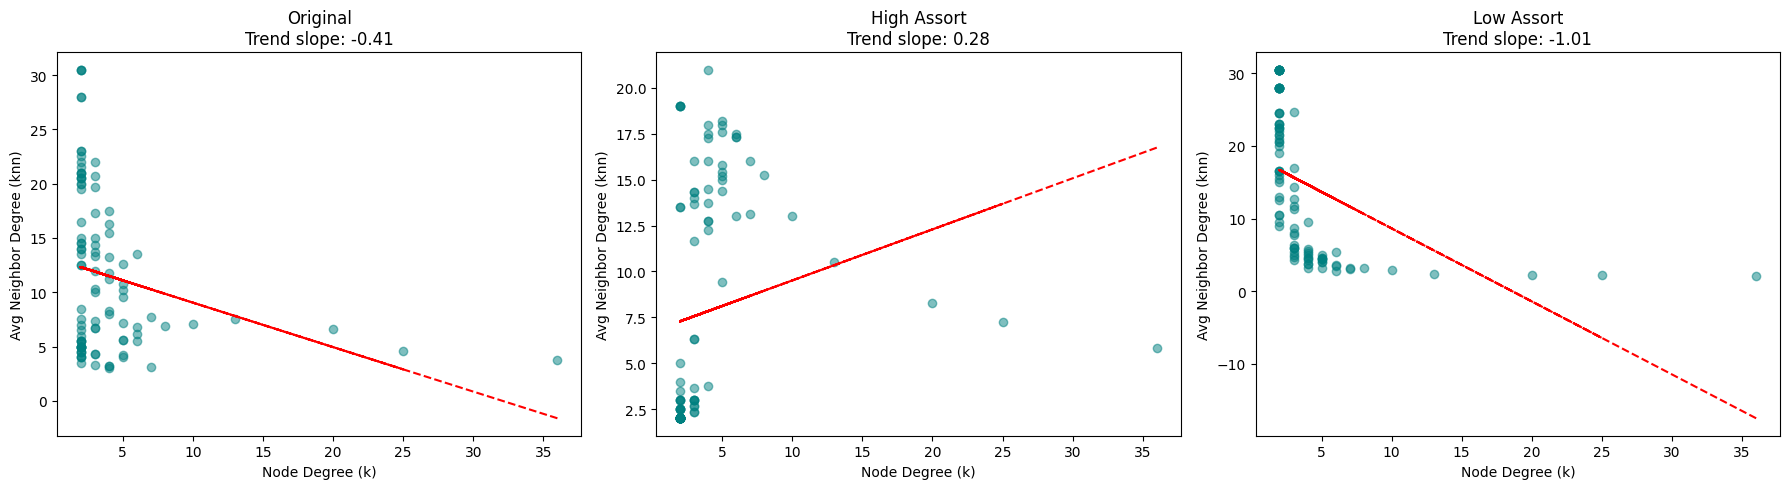

In [89]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
graphs = [("Original", G_base), ("High Assort", G_high), ("Low Assort", G_low)]

for i, (name, G) in enumerate(graphs):
    # Calculate average neighbor degree for every node
    knn = nx.average_neighbor_degree(G)
    degrees = dict(G.degree())
    
    # Prepare X and Y for scatter plot
    x = [degrees[n] for n in G.nodes()]
    y = [knn[n] for n in G.nodes()]
    
    axes[i].scatter(x, y, alpha=0.5, color='teal')
    
    # Add a trend line (Linear Regression)
    m, b = np.polyfit(x, y, 1)
    axes[i].plot(x, m*np.array(x) + b, color='red', linestyle='--')
    
    axes[i].set_title(f"{name}\nTrend slope: {m:.2f}")
    axes[i].set_xlabel("Node Degree (k)")
    axes[i].set_ylabel("Avg Neighbor Degree (knn)")

plt.tight_layout()
plt.show()

## 2. Network Layout Visualization

Purpose: To see the "physical" structure of the network.

What it proves: It visually shows the "Rich Club" effect. In high-assortativity graphs, you physically see hubs clumping together. In low-assortativity graphs, you see "Star" formations where hubs are isolated from each other.

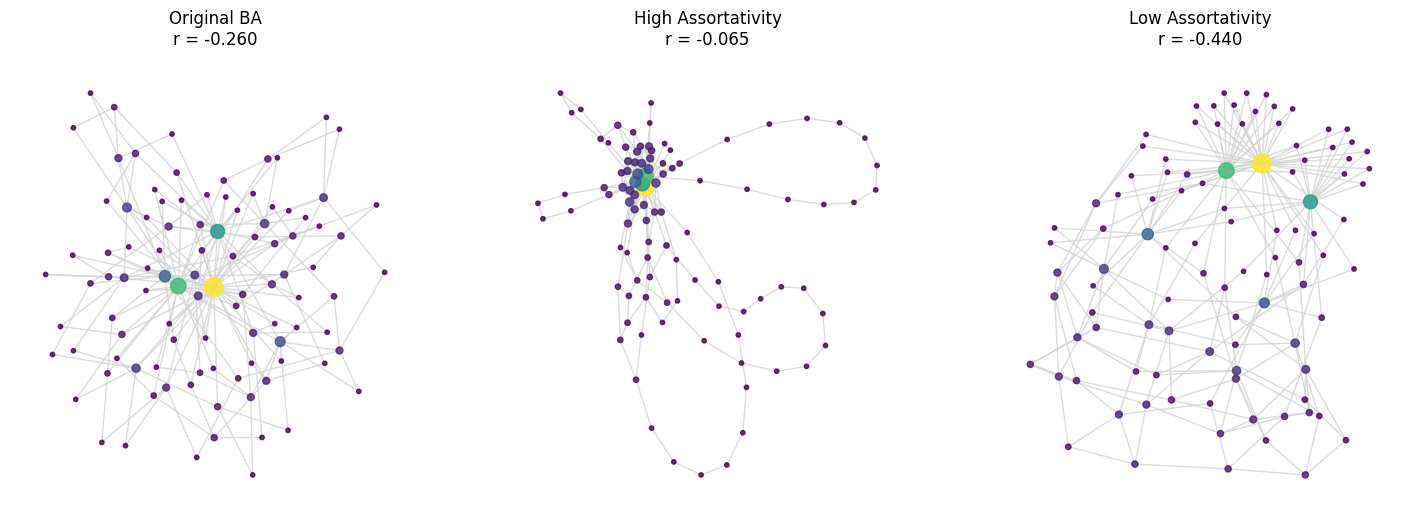

In [88]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
graphs = [("Original BA", G_base), ("High Assortativity", G_high), ("Low Assortativity", G_low)]

for i, (name, G) in enumerate(graphs):
    # Calculate degrees for sizing
    degrees = dict(G.degree())
    node_sizes = [v * 5 for v in degrees.values()]
    
    # Use spring_layout to let clusters form naturally
    pos = nx.spring_layout(G, seed=42)
    
    nx.draw(G, pos, ax=axes[i], node_size=node_sizes, 
            node_color=list(degrees.values()), 
            cmap=plt.cm.viridis, alpha=0.8, edge_color='lightgray')
    
    r = nx.degree_assortativity_coefficient(G)
    axes[i].set_title(f"{name}\nr = {r:.3f}")

plt.show()